In [2]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np

In [23]:
dfs = [pd.read_csv(f'data/{f}', sep='\t') for f in os.listdir('./data')]

dfs[0].sort_values(by='chromosome')

,chromosome,mean_value,std_dev
0,*,0.000000,0.000000
26,GL000008.2,0.333333,0.577350
27,GL000009.2,0.666667,0.577350
28,GL000194.1,0.666667,1.154701
29,GL000195.1,0.333333,0.577350
...,...,...,...
21,chr8,792.000000,209.942849
22,chr9,1215.333333,385.404117
23,chrM,1717.666667,610.609804
24,chrX,1184.000000,291.237017


In [20]:
n_chrom = 100
names = ['IVPA_Cyt', 'IVPA_Nuc', 'NP_Cyt', 'NP_Nuc']

X = np.arange(n_chrom+1)
X_labs = dfs[0].loc[:n_chrom, 'chromosome'].to_list()

Y, Y_err = [], []

for df in dfs:
    Y.append(df.loc[:n_chrom, 'mean_value'].to_numpy())
    Y_err.append(df.loc[:n_chrom, 'std_dev'].to_numpy())


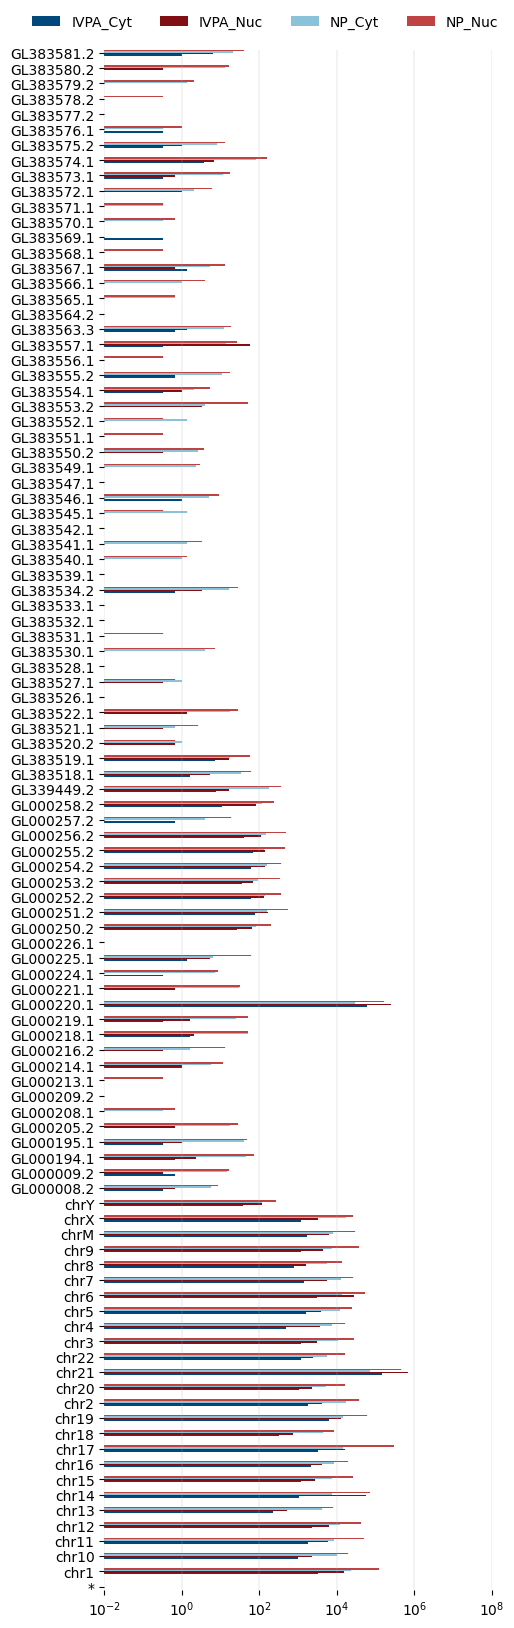

In [21]:
offs = [-0.15, -0.05, 0.05, 0.15]
cs = ['#01497c', '#800e13', '#89c2d9','#bf4342']

fig, ax = plt.subplots(1,1,figsize=(5,20))

for y, ye, off, name, c in zip(Y, Y_err, offs, names, cs):
    ax.barh(X+off, y, height=0.1, color=c, label=name)



ax.grid(which='major', axis='x', linewidth=0.2)
for s in ax.spines:
    ax.spines[s].set_visible(False)

ax.set_xscale('log')
# ax.xaxis.tick_top()
ax.set_xticks(ax.get_xticks()[::2])

ax.set_yticks(X)
ax.set_yticklabels(X_labs);
ax.set_ymargin(0)

ax.legend(frameon=False, ncol=4, loc=[-0.2, 1.01])